In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:

# Install required packages
!pip install scanpy squidpy anndata leidenalg -q

print("Done")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.2/

In [4]:
import os

# Check your uploaded files
base_path = "/content/drive/MyDrive/Spatial-raw-data(special project)/"
print(os.listdir(base_path))

['GSM8552953_PA22_filtered_feature_bc_matrix.h5', 'GSM8552946_PA05-2_filtered_feature_bc_matrix.h5', 'GSM8552950_PA11-2_filtered_feature_bc_matrix.h5', 'GSM8552951_PA12_filtered_feature_bc_matrix.h5']


# Imports

Load all the Python libraries we need for the analysis. Scanpy handles single-cell data processing, Squidpy handles spatial analysis, and Matplotlib handles plotting. Think of this as gathering all your tools before starting work.

In [5]:
import scanpy as sc
import squidpy as sq
import anndata
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

sc.settings.figdir = "/content/drive/MyDrive/spatial_pdac_results/"
sc.settings.set_figure_params(dpi=100, facecolor="white")

os.makedirs("/content/drive/MyDrive/spatial_pdac_results", exist_ok=True)
print("Ready")

Ready


# Load Slides

We read the gene expression files (.h5) for our 4 selected tumor samples into Python. Each sample becomes an AnnData object containing a table of spots × genes. We also label each sample as High-NI or Low-NI so we can compare them later.

In [8]:
import scanpy as sc
import os

base = "/content/drive/MyDrive/Spatial-raw-data(special project)/"

# Load each h5 file directly
file_map = {
    "HighNI_PA05": "GSM8552946_PA05-2_filtered_feature_bc_matrix.h5",
    "HighNI_PA11": "GSM8552950_PA11-2_filtered_feature_bc_matrix.h5",
    "LowNI_PA12":  "GSM8552951_PA12_filtered_feature_bc_matrix.h5",
    "LowNI_PA22":  "GSM8552953_PA22_filtered_feature_bc_matrix.h5",
}

slides = {}
for name, filename in file_map.items():
    path = os.path.join(base, filename)
    adata = sc.read_10x_h5(path)   # different function — reads h5 directly
    adata.var_names_make_unique()
    adata.obs["sample_id"] = name
    adata.obs["NI_status"] = "High" if "High" in name else "Low"
    slides[name] = adata
    print(f"Loaded {name}: {adata.shape[0]} cells, {adata.shape[1]} genes")

Loaded HighNI_PA05: 4992 cells, 18085 genes
Loaded HighNI_PA11: 4990 cells, 18085 genes
Loaded LowNI_PA12: 4855 cells, 18085 genes
Loaded LowNI_PA22: 4322 cells, 18085 genes


# Quality Control QC

We remove poor quality tissue spots that would give misleading results. Spots with too few genes detected are likely empty tissue, and spots with high mitochondrial gene activity are likely dead or damaged cells. Filtering these out ensures our downstream analysis reflects real biology.

In [9]:
# Purpose: remove dead/empty tissue spots
for name, adata in slides.items():
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(
        adata, qc_vars=["mt"], percent_top=None, inplace=True
    )
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)
    slides[name] = adata[adata.obs["pct_counts_mt"] < 25].copy()
    print(f"{name}: {slides[name].shape[0]} spots kept")

HighNI_PA05: 4990 spots kept
HighNI_PA11: 4988 spots kept
LowNI_PA12: 4854 spots kept
LowNI_PA22: 4321 spots kept


# Normalize + Cluster

We scale the data so all spots are comparable regardless of how deeply they were sequenced. Then we reduce 30,000 genes down to key dimensions using PCA, visualize in 2D using UMAP, and group similar spots together using Leiden clustering. Each cluster likely represents a distinct cell type or tissue region.

In [10]:
# Purpose: make spots comparable, group similar spots
for name, adata in slides.items():
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, n_comps=20)
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=20)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, resolution=0.5, key_added="leiden_spatial")
    slides[name] = adata
    print(f"{name} done")

HighNI_PA05 done
HighNI_PA11 done
LowNI_PA12 done
LowNI_PA22 done


# Spatial Cluster Plots

We visualize which clusters appear in each tumor sample using UMAP plots. Since we don't have the tissue image coordinates uploaded, we show clusters in reduced dimensional space instead. This tells us how many distinct cell populations exist in each sample.

In [12]:
# Using UMAP instead of tissue image (spatial folders not available)
import os
os.makedirs("/content/drive/MyDrive/spatial-transcriptomics-esp", exist_ok=True)

for name, adata in slides.items():
    sc.pl.umap(
        adata,
        color="leiden_spatial",
        title=f"{name} — Clusters",
        save=f"clusters_{name}.png",
        show=False
    )
    print(f"Saved clusters_{name}.png")

Saved clusters_HighNI_PA05.png
Saved clusters_HighNI_PA11.png
Saved clusters_LowNI_PA12.png
Saved clusters_LowNI_PA22.png


# Marker Genes on Tissue

We plot the expression of known marker genes for key cell types including Schwann cells (TGFBI, S100B), macrophages (CD68), fibroblasts (COL1A1), and tumor cells (EPCAM). Seeing where these genes are highly expressed tells us which clusters correspond to which cell types.

In [14]:
# Marker genes on UMAP (no spatial coords needed)
markers = {
    "Schwann_TGFBI": ["TGFBI", "S100B", "MPZ"],
    "Macrophage":    ["CD68", "MRC1"],
    "Fibroblast":    ["COL1A1", "ACTA2"],
    "Tumor":         ["EPCAM", "KRT19"],
}

for name, adata in slides.items():
    for cell_type, genes in markers.items():
        present = [g for g in genes if g in adata.var_names]
        if not present:
            print(f"Skipping {cell_type} in {name}")
            continue
        sc.pl.umap(
            adata,
            color=present,
            title=f"{name} — {cell_type}",
            save=f"markers_{cell_type}_{name}.png",
            show=False
        )
        print(f"Saved markers_{cell_type}_{name}.png")

Saved markers_Schwann_TGFBI_HighNI_PA05.png
Saved markers_Macrophage_HighNI_PA05.png
Saved markers_Fibroblast_HighNI_PA05.png
Saved markers_Tumor_HighNI_PA05.png
Saved markers_Schwann_TGFBI_HighNI_PA11.png
Saved markers_Macrophage_HighNI_PA11.png
Saved markers_Fibroblast_HighNI_PA11.png
Saved markers_Tumor_HighNI_PA11.png
Saved markers_Schwann_TGFBI_LowNI_PA12.png
Saved markers_Macrophage_LowNI_PA12.png
Saved markers_Fibroblast_LowNI_PA12.png
Saved markers_Tumor_LowNI_PA12.png
Saved markers_Schwann_TGFBI_LowNI_PA22.png
Saved markers_Macrophage_LowNI_PA22.png
Saved markers_Fibroblast_LowNI_PA22.png
Saved markers_Tumor_LowNI_PA22.png


# High vs Low NI Comparison

We merge all 4 slides into one combined object and run UMAP again coloring spots by NI status. This shows whether High-NI and Low-NI tumors have fundamentally different cell population compositions. If they separate on the UMAP it confirms the biology is different between the two groups.

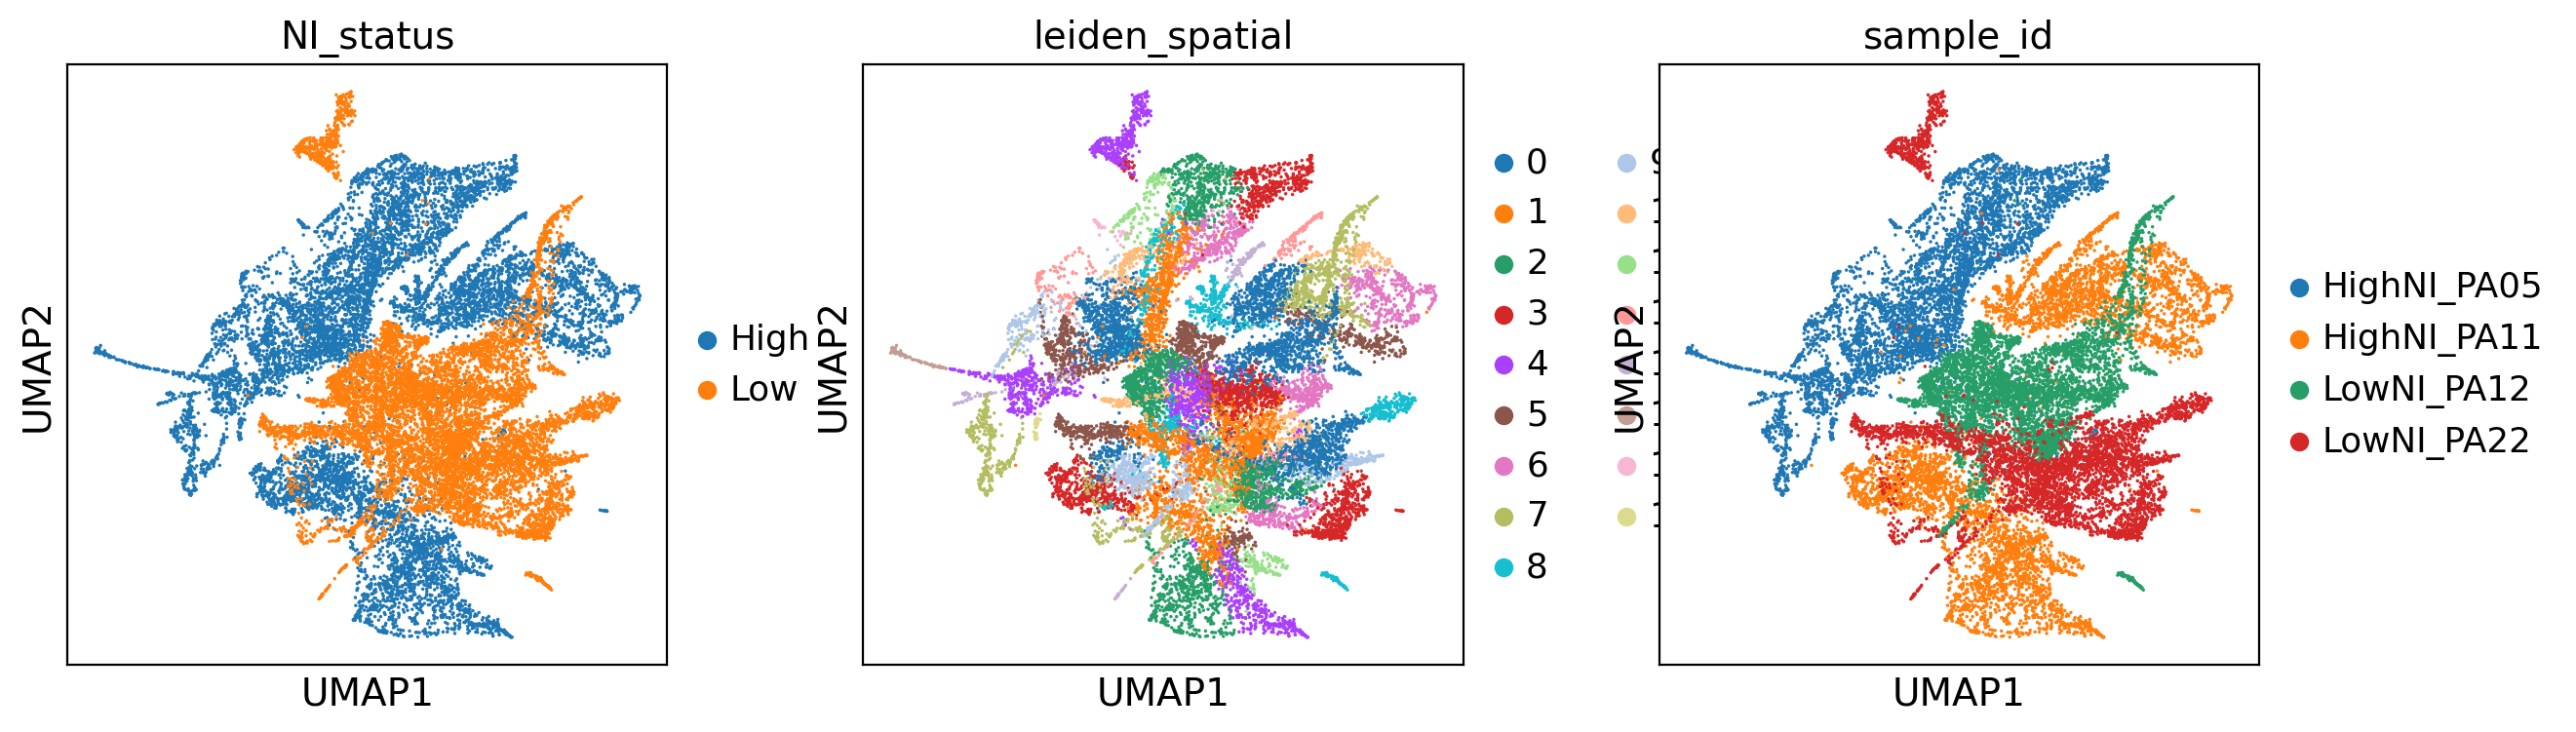

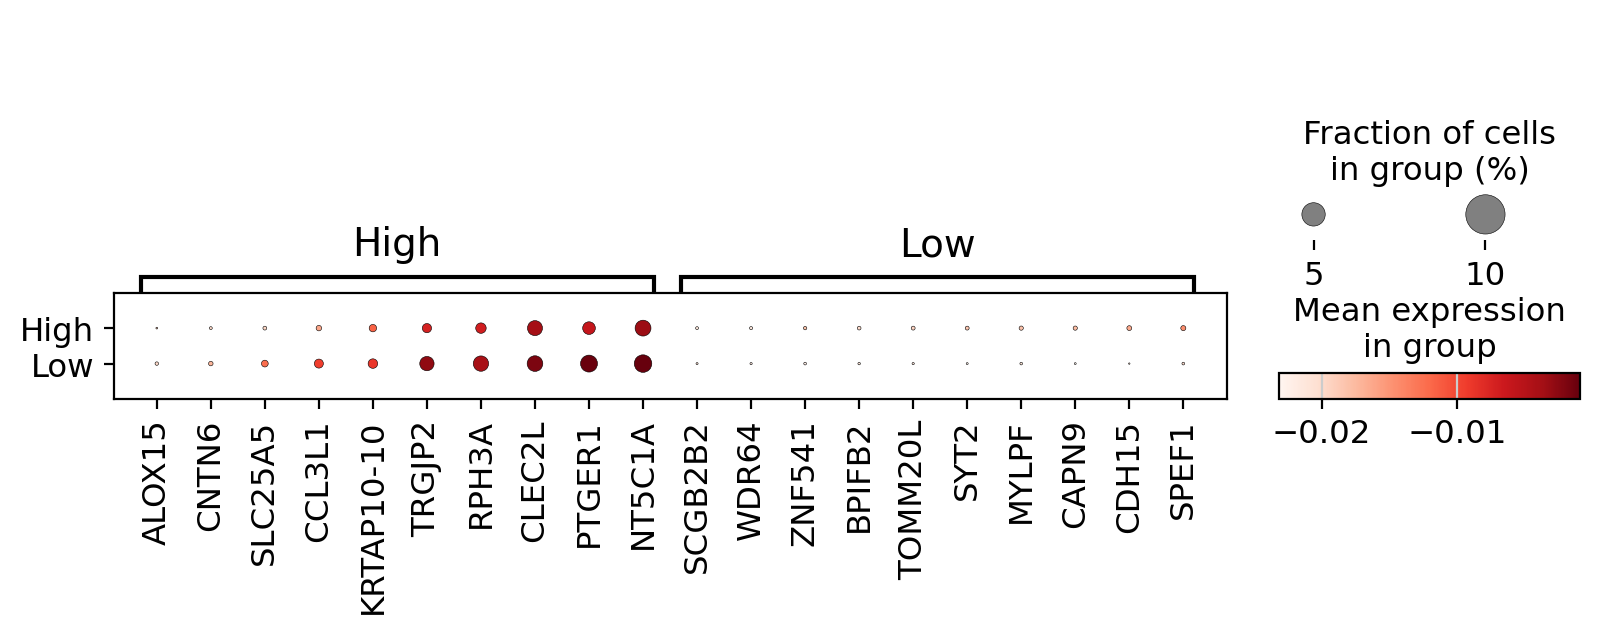

Done


In [15]:
# Purpose: the main comparison — do invaded tumors look different?
combined = anndata.concat(
    list(slides.values()),
    label="sample_id",
    keys=list(slides.keys()),
    uns_merge="first"
)

sc.pp.neighbors(combined, n_neighbors=10, n_pcs=20)
sc.tl.umap(combined)

sc.pl.umap(
    combined,
    color=["NI_status", "leiden_spatial", "sample_id"],
    save="combined_umap.png"
)

# Differential expression
sc.tl.rank_genes_groups(
    combined, groupby="NI_status",
    method="wilcoxon", key_added="NI_DE"
)
sc.pl.rank_genes_groups_dotplot(
    combined, groupby="NI_status",
    key="NI_DE", n_genes=10,
    save="DE_highNI_vs_lowNI.png"
)
print("Done")

# Neighborhood Enrichment

In [17]:
# Skipping neighborhood enrichment (needs spatial coords)
# Instead: cluster composition comparison between High and Low NI

import matplotlib.pyplot as plt
import pandas as pd

for name, adata in slides.items():
    # Count cells per cluster
    cluster_counts = adata.obs["leiden_spatial"].value_counts()

    fig, ax = plt.subplots(figsize=(8, 5))
    cluster_counts.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"{name} — Cells per Cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Number of Spots")
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/spatial_pdac_results/cluster_counts_{name}.png",
                dpi=150)
    plt.close()
    print(f"Saved cluster_counts_{name}.png")

# Compare cluster proportions High vs Low NI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, adata) in zip(axes, slides.items()):
    props = adata.obs["leiden_spatial"].value_counts(normalize=True)
    props.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"{name} — Cluster Proportions")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Proportion")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/spatial_pdac_results/cluster_proportions_comparison.png",
            dpi=150)
plt.close()
print("Saved cluster_proportions_comparison.png")

Saved cluster_counts_HighNI_PA05.png
Saved cluster_counts_HighNI_PA11.png
Saved cluster_counts_LowNI_PA12.png
Saved cluster_counts_LowNI_PA22.png
Saved cluster_proportions_comparison.png


# Differential Expression

We statistically compare gene expression between High-NI and Low-NI spots across all samples. The Wilcoxon test identifies genes significantly upregulated or downregulated in nerve-invaded tumors. This tells us which molecular programs are active specifically in tumors with neural invasion.

In [18]:
import scanpy as sc

# Compare gene expression High-NI vs Low-NI
sc.tl.rank_genes_groups(
    combined,
    groupby="NI_status",
    method="wilcoxon",
    key_added="NI_DE"
)

sc.pl.rank_genes_groups_dotplot(
    combined,
    groupby="NI_status",
    key="NI_DE",
    n_genes=10,
    save="DE_highNI_vs_lowNI.png",
    show=False
)
print("Saved DE_highNI_vs_lowNI.png")

Saved DE_highNI_vs_lowNI.png


# Volcano Plot

We visualize the differential expression results as a volcano plot showing fold change on the x-axis and statistical significance on the y-axis. Red dots are genes significantly upregulated in High-NI tumors, blue dots are downregulated. The top labeled genes are the most biologically interesting candidates.

        names      scores  logfoldchanges  pvals  pvals_adj
0      ALOX15  118.805611       -0.119688    0.0        0.0
1       CNTN6  118.416016        0.201804    0.0        0.0
2     SLC25A5  117.454727        0.667849    0.0        0.0
3      CCL3L1  116.392265        0.775012    0.0        0.0
4  KRTAP10-10  116.140793        0.383715    0.0        0.0
['names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj']


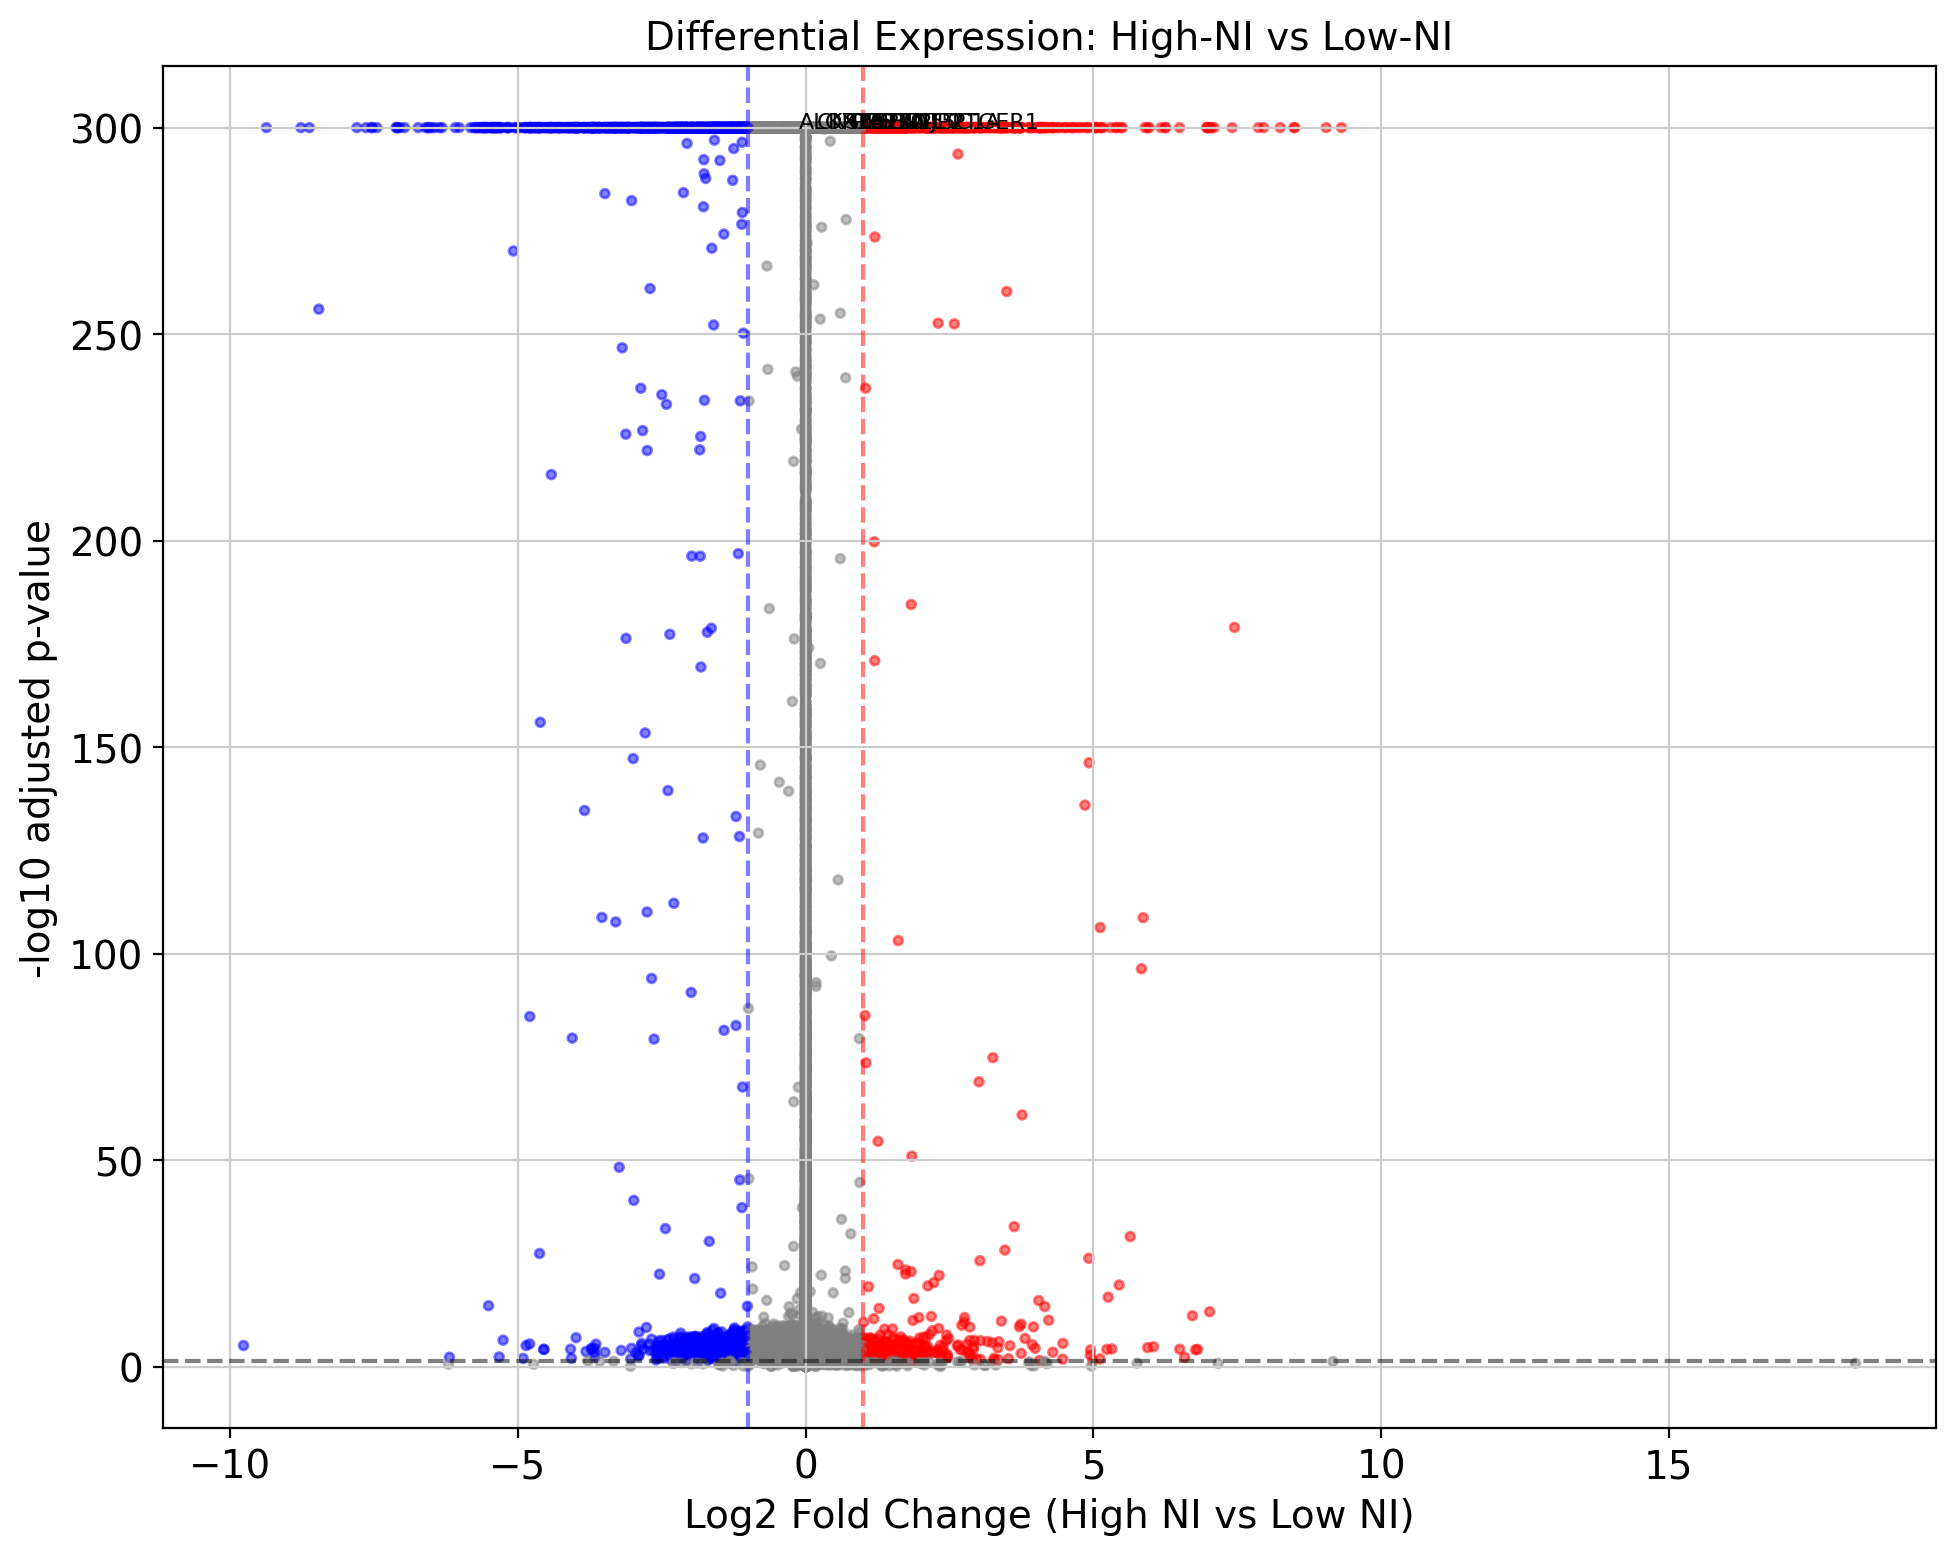

Saved volcano_plot.png


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Get DE results for High NI group
result = sc.get.rank_genes_groups_df(
    combined,
    group="High",
    key="NI_DE"
)

print(result.head())
print(result.columns.tolist())

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

result['color'] = 'grey'
result.loc[(result['logfoldchanges'] > 1) &
           (result['pvals_adj'] < 0.05), 'color'] = 'red'
result.loc[(result['logfoldchanges'] < -1) &
           (result['pvals_adj'] < 0.05), 'color'] = 'blue'

ax.scatter(
    result['logfoldchanges'],
    -np.log10(result['pvals_adj'] + 1e-300),
    c=result['color'],
    alpha=0.5,
    s=10
)

# Label top 10 genes
top_genes = result.nsmallest(10, 'pvals_adj')
for _, row in top_genes.iterrows():
    ax.annotate(
        row['names'],
        (row['logfoldchanges'], -np.log10(row['pvals_adj'] + 1e-300)),
        fontsize=8
    )

ax.axvline(x=1,  color='red',   linestyle='--', alpha=0.5)
ax.axvline(x=-1, color='blue',  linestyle='--', alpha=0.5)
ax.axhline(y=-np.log10(0.05), color='black', linestyle='--', alpha=0.5)

ax.set_xlabel('Log2 Fold Change (High NI vs Low NI)')
ax.set_ylabel('-log10 adjusted p-value')
ax.set_title('Differential Expression: High-NI vs Low-NI')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/spatial_pdac_results/volcano_plot.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved volcano_plot.png")

# Cluster Proportions

Since neighborhood enrichment requires spatial coordinates we instead compare how much of each cluster is present in High-NI vs Low-NI samples. If a certain cluster is much more abundant in High-NI tumors it suggests that cell type plays a role in neural invasion.

In [20]:
import matplotlib.pyplot as plt

# Per sample cluster counts
for name, adata in slides.items():
    cluster_counts = adata.obs["leiden_spatial"].value_counts()

    fig, ax = plt.subplots(figsize=(8, 5))
    cluster_counts.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"{name} — Cells per Cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Number of Spots")
    plt.tight_layout()
    plt.savefig(
        f"/content/drive/MyDrive/spatial_pdac_results/cluster_counts_{name}.png",
        dpi=150
    )
    plt.close()
    print(f"Saved cluster_counts_{name}.png")

# Side by side comparison High vs Low NI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, adata) in zip(axes, slides.items()):
    props = adata.obs["leiden_spatial"].value_counts(normalize=True)
    props.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"{name} — Cluster Proportions")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Proportion")

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/spatial_pdac_results/cluster_proportions_comparison.png",
    dpi=150
)
plt.close()
print("Saved cluster_proportions_comparison.png")

Saved cluster_counts_HighNI_PA05.png
Saved cluster_counts_HighNI_PA11.png
Saved cluster_counts_LowNI_PA12.png
Saved cluster_counts_LowNI_PA22.png
Saved cluster_proportions_comparison.png
